# Data Transformation, Encoding & Visualization
### rearranged_columns.csv — Petrol Prices & Country Impact

## 1. Load & Inspect

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('rearranged_columns.csv')
print('Shape:', df.shape)
df.head()

Shape: (13, 23)


,ISO,Country,Inflation_Risk,Currency_Pressure,Population_M,Currency,Before_War_Price,After_War_Price,Amount_Change,Pct_Increase,...,GDP_Impact_Pct,Price_Difference,Oil_Import_Pct,Unit,Policy_Response,Stock_Market_Change,Vulnerability,Region_x,Oil_Import_Dep,Region_y
0,PAK,Pakistan,Very High,Severe,240,PKR,266.17,321.17,55.0,20.66,...,-1.8,0.20,85,PKR/L,Emergency fuel price hike,-4.2,Critical,south asia,High,South Asia
1,IND,India,High,High,1440,INR,94.77,94.77,0.0,0.00,...,-1.2,0.00,85,INR/L,Strategic reserves released; prices frozen,-3.1,High,south asia,High,South Asia
2,BGD,Bangladesh,Very High,Severe,175,BDT,125.00,130.00,5.0,4.00,...,-2.0,0.04,95,BDT/L,University closures to save electricity,-3.8,Critical,south asia,High,South Asia
3,LKA,Sri Lanka,Very High,Severe,22,LKR,365.00,370.00,5.0,1.37,...,-2.5,0.02,100,LKR/L,Rationing measures introduced,-5.0,Critical,south asia,High,South Asia
4,NPL,Nepal,High,High,30,NPR,186.00,190.00,4.0,2.15,...,-1.5,0.03,100,NPR/L,Price adjustment; subsidies for transport,-2.8,High,south asia,High,South Asia


In [26]:
df.info()
print('\nMissing values:\n', df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ISO                  13 non-null     str    
 1   Country              13 non-null     str    
 2   Inflation_Risk       13 non-null     str    
 3   Currency_Pressure    13 non-null     str    
 4   Population_M         13 non-null     int64  
 5   Currency             13 non-null     str    
 6   Before_War_Price     13 non-null     float64
 7   After_War_Price      13 non-null     float64
 8   Amount_Change        13 non-null     float64
 9   Pct_Increase         13 non-null     float64
 10  Trend                13 non-null     str    
 11  Before_War_USD       13 non-null     float64
 12  After_War_USD        13 non-null     float64
 13  GDP_Impact_Pct       13 non-null     float64
 14  Price_Difference     13 non-null     float64
 15  Oil_Import_Pct       13 non-null     int64  
 16  Uni

In [27]:
df.describe()

,Population_M,Before_War_Price,After_War_Price,Amount_Change,Pct_Increase,Before_War_USD,After_War_USD,GDP_Impact_Pct,Price_Difference,Oil_Import_Pct,Stock_Market_Change
count,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000,13.000000
mean,311.307692,83.473846,88.961538,5.487692,5.343077,1.081538,1.134615,-1.423077,0.053077,57.000000,-4.000000
std,506.476124,120.548014,129.424011,15.009794,4.994137,0.433318,0.442730,2.266478,0.048885,41.450774,3.492611
min,10.000000,0.300000,0.320000,0.000000,0.000000,0.300000,0.320000,-8.000000,0.000000,0.000000,-15.000000
25%,37.000000,0.850000,0.900000,0.040000,3.850000,0.850000,0.900000,-1.800000,0.030000,5.000000,-4.200000
50%,86.000000,1.820000,1.890000,0.070000,4.620000,1.130000,1.150000,-1.200000,0.040000,72.000000,-3.100000
75%,240.000000,125.000000,130.000000,4.000000,5.880000,1.200000,1.260000,-0.500000,0.060000,89.000000,-2.500000
max,1440.000000,365.000000,370.000000,55.000000,20.660000,1.820000,1.890000,1.500000,0.200000,100.000000,-1.200000


## 2. Data Cleaning & Type Fixes

In [28]:
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.strip()

df['Region'] = df['Region_y'].fillna(df['Region_x'])
df.drop(columns=['Region_x', 'Region_y'], inplace=True)

df['Region']  = df['Region'].str.title()
df['Country'] = df['Country'].str.strip()

print('Cleaned. Shape:', df.shape)
print(df[['Country','Region','Inflation_Risk','Vulnerability']].head(8))

Cleaned. Shape: (13, 22)
      Country       Region Inflation_Risk Vulnerability
0    Pakistan   South Asia      Very High      Critical
1       India   South Asia           High          High
2  Bangladesh   South Asia      Very High      Critical
3   Sri Lanka   South Asia      Very High      Critical
4       Nepal   South Asia           High          High
5       China    East Asia       Moderate      Moderate
6      Turkey  Europe/Asia      Very High          High
7     Germany       Europe       Moderate      Moderate


## 3. Feature Engineering

In [29]:
df['Price_Change_Ratio'] = (df['After_War_USD'] / df['Before_War_USD']).round(4)

df['USD_Price_Diff'] = (df['After_War_USD'] - df['Before_War_USD']).round(4)

df['Oil_Import_Norm'] = (df['Oil_Import_Pct'] / 100).round(4)

df['GDP_Severity'] = pd.cut(
    df['GDP_Impact_Pct'],
    bins=[-np.inf, -4, -2, 0, np.inf],
    labels=['Extreme', 'Severe', 'Mild', 'Positive']
)

df['High_Import_Flag'] = (df['Oil_Import_Pct'] >= 75).astype(int)

print('New features added.')
df[['Country','Price_Change_Ratio','USD_Price_Diff','GDP_Severity','High_Import_Flag']].head(7)

New features added.


,Country,Price_Change_Ratio,USD_Price_Diff,GDP_Severity,High_Import_Flag
0,Pakistan,1.2105,0.20,Mild,1
1,India,1.0000,0.00,Mild,1
2,Bangladesh,1.0392,0.04,Severe,1
3,Sri Lanka,1.0167,0.02,Severe,1
4,Nepal,1.0214,0.03,Mild,1
5,China,1.0500,0.06,Mild,0
6,Turkey,1.0531,0.06,Mild,1


## 4. Label Encoding

In [30]:
le = LabelEncoder()
le_cols = ['Trend', 'Oil_Import_Dep', 'Inflation_Risk', 'Currency_Pressure', 'Vulnerability', 'Region']

for col in le_cols:
    if col in df.columns:
        df[col + '_LE'] = le.fit_transform(df[col].astype(str))
        print(f'{col:20s} => {dict(zip(le.classes_, le.transform(le.classes_)))}')

Trend                => {'Increase': np.int64(0), 'Stable': np.int64(1)}
Oil_Import_Dep       => {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}
Inflation_Risk       => {'Extreme': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3), 'Very High': np.int64(4)}
Currency_Pressure    => {'Extreme': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3), 'Severe': np.int64(4)}
Vulnerability        => {'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Moderate': np.int64(3)}
Region               => {'East Asia': np.int64(0), 'Europe': np.int64(1), 'Europe/Asia': np.int64(2), 'Middle East': np.int64(3), 'North America': np.int64(4), 'South Asia': np.int64(5)}


## 5. Ordinal Encoding

In [31]:
ordinal_configs = {
    'Inflation_Risk':    [['Low', 'Moderate', 'High', 'Very High', 'Extreme']],
    'Currency_Pressure': [['Low', 'Moderate', 'High', 'Severe', 'Extreme']],
    'Vulnerability':     [['Low', 'Moderate', 'High', 'Critical']],
    'Oil_Import_Dep':    [['Low', 'Medium', 'High']],
}

for col, cats in ordinal_configs.items():
    if col in df.columns:
        oe = OrdinalEncoder(categories=cats, handle_unknown='use_encoded_value', unknown_value=-1)
        df[col + '_OE'] = oe.fit_transform(df[[col]]).astype(int)
        print(f'{col:20s} => {dict(zip(cats[0], range(len(cats[0]))))}')

Inflation_Risk       => {'Low': 0, 'Moderate': 1, 'High': 2, 'Very High': 3, 'Extreme': 4}
Currency_Pressure    => {'Low': 0, 'Moderate': 1, 'High': 2, 'Severe': 3, 'Extreme': 4}
Vulnerability        => {'Low': 0, 'Moderate': 1, 'High': 2, 'Critical': 3}
Oil_Import_Dep       => {'Low': 0, 'Medium': 1, 'High': 2}


## 6. One-Hot Encoding

In [32]:
df_ohe = pd.get_dummies(df, columns=['Region', 'Trend'], prefix=['Region', 'Trend'], drop_first=False)
ohe_new_cols = [c for c in df_ohe.columns if c.startswith('Region_') or c.startswith('Trend_')]
print('One-hot columns created:', ohe_new_cols)
df_ohe[ohe_new_cols].head()

One-hot columns created: ['Trend_LE', 'Region_LE', 'Region_East Asia', 'Region_Europe', 'Region_Europe/Asia', 'Region_Middle East', 'Region_North America', 'Region_South Asia', 'Trend_Increase', 'Trend_Stable']


,Trend_LE,Region_LE,Region_East Asia,Region_Europe,Region_Europe/Asia,Region_Middle East,Region_North America,Region_South Asia,Trend_Increase,Trend_Stable
0,0,5,False,False,False,False,False,True,True,False
1,1,5,False,False,False,False,False,True,False,True
2,0,5,False,False,False,False,False,True,True,False
3,0,5,False,False,False,False,False,True,True,False
4,0,5,False,False,False,False,False,True,True,False


## 7. Frequency & Target Encoding

In [33]:
freq = df['Region'].value_counts(normalize=True)
df['Region_FreqEnc'] = df['Region'].map(freq).round(4)
print('Region frequency encoding:')
print(df[['Region','Region_FreqEnc']].drop_duplicates().sort_values('Region_FreqEnc', ascending=False))

tgt = df.groupby('Region')['GDP_Impact_Pct'].mean()
df['Region_TargetEnc'] = df['Region'].map(tgt).round(4)
print('\nRegion target encoding (mean GDP Impact %):')
print(df[['Region','Region_TargetEnc']].drop_duplicates().sort_values('Region_TargetEnc'))

Region frequency encoding:
           Region  Region_FreqEnc
0      South Asia          0.3846
10    Middle East          0.2308
7          Europe          0.1538
5       East Asia          0.0769
6     Europe/Asia          0.0769
9   North America          0.0769

Region target encoding (mean GDP Impact %):
           Region  Region_TargetEnc
10    Middle East             -1.90
0      South Asia             -1.80
6     Europe/Asia             -1.60
5       East Asia             -0.80
7          Europe             -0.55
9   North America             -0.30


## 8. Min-Max & Standard Scaling

In [34]:
scale_cols = ['Before_War_USD', 'After_War_USD', 'GDP_Impact_Pct',
              'Oil_Import_Pct', 'Stock_Market_Change', 'Population_M']
scale_cols = [c for c in scale_cols if c in df.columns]

mm = MinMaxScaler()
ss = StandardScaler()
df[[c + '_MM' for c in scale_cols]] = mm.fit_transform(df[scale_cols])
df[[c + '_SS' for c in scale_cols]] = ss.fit_transform(df[scale_cols])

print('Min-Max scaled columns:')
print(df[[c + '_MM' for c in scale_cols]].describe().round(3))

Min-Max scaled columns:
       Before_War_USD_MM  After_War_USD_MM  GDP_Impact_Pct_MM  \
count             13.000            13.000             13.000   
mean               0.514             0.519              0.692   
std                0.285             0.282              0.239   
min                0.000             0.000              0.000   
25%                0.362             0.369              0.653   
50%                0.546             0.529              0.716   
75%                0.592             0.599              0.789   
max                1.000             1.000              1.000   

       Oil_Import_Pct_MM  Stock_Market_Change_MM  Population_M_MM  
count             13.000                  13.000           13.000  
mean               0.570                   0.797            0.211  
std                0.415                   0.253            0.354  
min                0.000                   0.000            0.000  
25%                0.050                   0.783  

## 9. Log Transformation

In [35]:
log_cols = ['Population_M', 'Oil_Import_Pct', 'Before_War_USD']
for col in log_cols:
    if col in df.columns:
        df[col + '_Log'] = np.log1p(df[col]).round(4)
        print(f'{col}_Log — min: {df[col+"_Log"].min():.3f}  max: {df[col+"_Log"].max():.3f}')

print('\nFinal dataframe shape:', df.shape)
df.head(3)

Population_M_Log — min: 2.398  max: 7.273
Oil_Import_Pct_Log — min: 0.000  max: 4.615
Before_War_USD_Log — min: 0.262  max: 1.037

Final dataframe shape: (13, 54)


,ISO,Country,Inflation_Risk,Currency_Pressure,Population_M,Currency,Before_War_Price,After_War_Price,Amount_Change,Pct_Increase,...,Population_M_MM,Before_War_USD_SS,After_War_USD_SS,GDP_Impact_Pct_SS,Oil_Import_Pct_SS,Stock_Market_Change_SS,Population_M_SS,Population_M_Log,Oil_Import_Pct_Log,Before_War_USD_Log
0,PAK,Pakistan,Very High,Severe,240,PKR,266.17,321.17,55.0,20.66,...,0.160839,-0.315957,0.036168,-0.173094,0.703083,-0.059602,-0.146541,5.4848,4.4543,0.6678
1,IND,India,High,High,1440,INR,94.77,94.77,0.0,0.00,...,1.000000,0.140425,0.012659,0.102443,0.703083,0.268209,2.319517,7.2731,4.4543,0.7608
2,BGD,Bangladesh,Very High,Severe,175,BDT,125.00,130.00,5.0,4.00,...,0.115385,-0.147816,-0.175416,-0.264940,0.954184,0.059602,-0.280119,5.1705,4.5643,0.7031


## 10. Save Encoded Dataset

In [36]:
df.to_csv('rearranged_encoded.csv', index=False)
print('Saved: rearranged_encoded.csv  |  Shape:', df.shape)

Saved: rearranged_encoded.csv  |  Shape: (13, 54)


---
## 11. Visualizations
### 11.1 Distributions of Key Numeric Columns

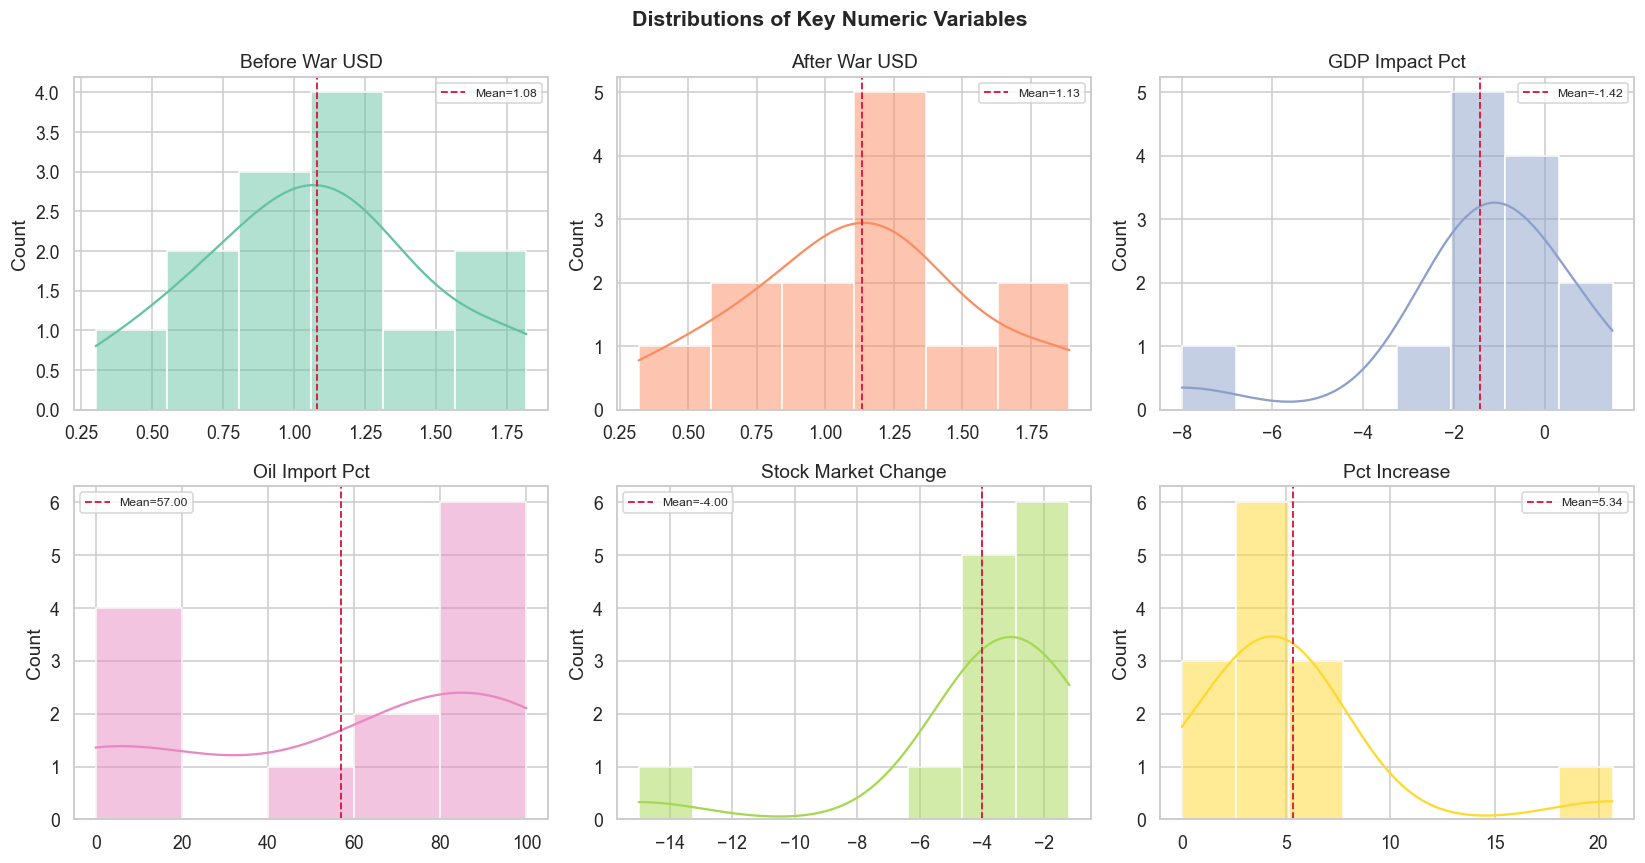

In [37]:
num_cols = ['Before_War_USD', 'After_War_USD', 'GDP_Impact_Pct',
            'Oil_Import_Pct', 'Stock_Market_Change', 'Pct_Increase']
num_cols = [c for c in num_cols if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distributions of Key Numeric Variables', fontsize=14, fontweight='bold')

colors = sns.color_palette('Set2', len(num_cols))
for ax, col, color in zip(axes.flat, num_cols, colors):
    sns.histplot(df[col], kde=True, ax=ax, color=color, edgecolor='white')
    ax.axvline(df[col].mean(), color='crimson', linestyle='--', linewidth=1.2,
               label=f'Mean={df[col].mean():.2f}')
    ax.set_title(col.replace('_', ' '))
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('v01_distributions.png', bbox_inches='tight')
plt.show()

### 11.2 Before vs After War Price per Country

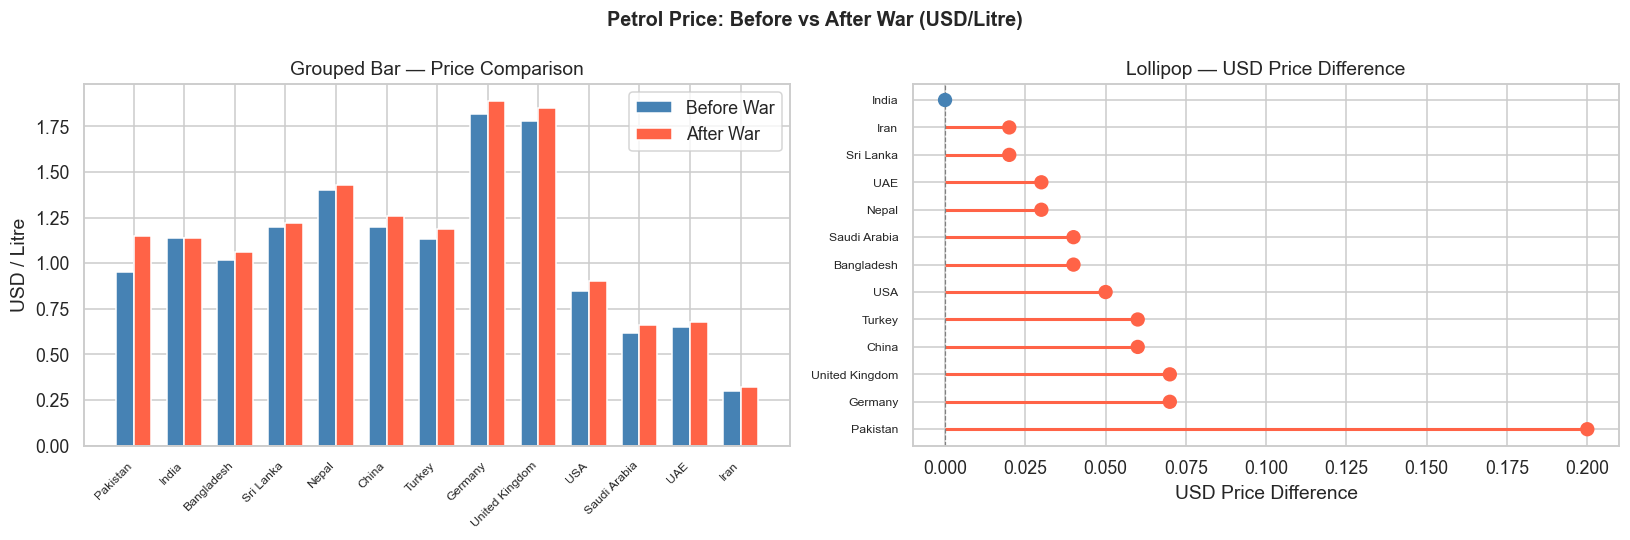

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Petrol Price: Before vs After War (USD/Litre)', fontsize=13, fontweight='bold')

x = np.arange(len(df))
w = 0.35
axes[0].bar(x - w/2, df['Before_War_USD'], w, label='Before War', color='steelblue', edgecolor='white')
axes[0].bar(x + w/2, df['After_War_USD'],  w, label='After War',  color='tomato',    edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df['Country'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('USD / Litre')
axes[0].set_title('Grouped Bar — Price Comparison')
axes[0].legend()

sd = df.sort_values('USD_Price_Diff', ascending=False)
colors = ['tomato' if v > 0 else 'steelblue' for v in sd['USD_Price_Diff']]
axes[1].hlines(range(len(sd)), 0, sd['USD_Price_Diff'], colors=colors, linewidth=2)
axes[1].scatter(sd['USD_Price_Diff'], range(len(sd)), color=colors, s=70, zorder=5)
axes[1].set_yticks(range(len(sd)))
axes[1].set_yticklabels(sd['Country'], fontsize=8)
axes[1].axvline(0, color='grey', linewidth=0.8, linestyle='--')
axes[1].set_xlabel('USD Price Difference')
axes[1].set_title('Lollipop — USD Price Difference')

plt.tight_layout()
plt.savefig('v02_price_comparison.png', bbox_inches='tight')
plt.show()

### 11.3 Country-wise Economic Indicators

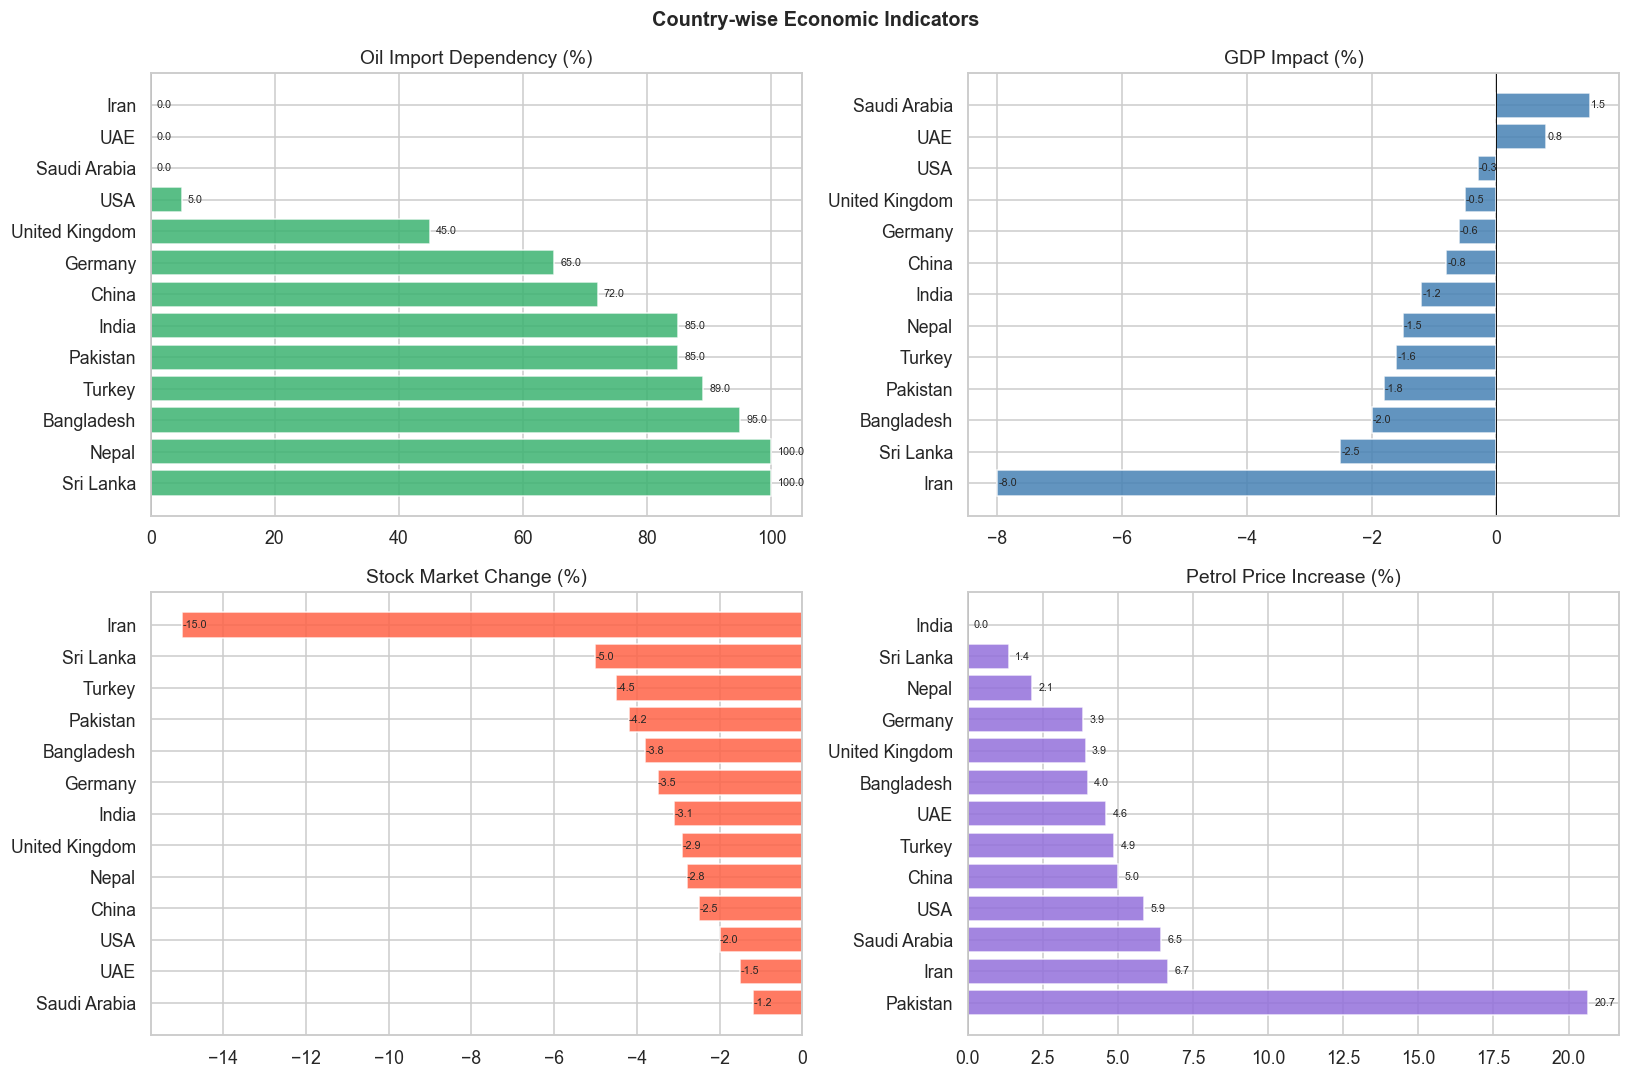

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Country-wise Economic Indicators', fontsize=13, fontweight='bold')

metrics = [
    ('Oil_Import_Pct',      'Oil Import Dependency (%)', 'mediumseagreen'),
    ('GDP_Impact_Pct',      'GDP Impact (%)',            'steelblue'),
    ('Stock_Market_Change', 'Stock Market Change (%)',   'tomato'),
    ('Pct_Increase',        'Petrol Price Increase (%)', 'mediumpurple'),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    sd = df.sort_values(col, ascending=(col == 'GDP_Impact_Pct'))
    bars = ax.barh(sd['Country'], sd[col], color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title)
    ax.axvline(0, color='black', linewidth=0.6)
    for bar, val in zip(bars, sd[col]):
        ax.text(bar.get_width() + abs(sd[col].max()) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}', va='center', fontsize=7)

plt.tight_layout()
plt.savefig('v03_country_indicators.png', bbox_inches='tight')
plt.show()

### 11.4 Correlation Heatmap

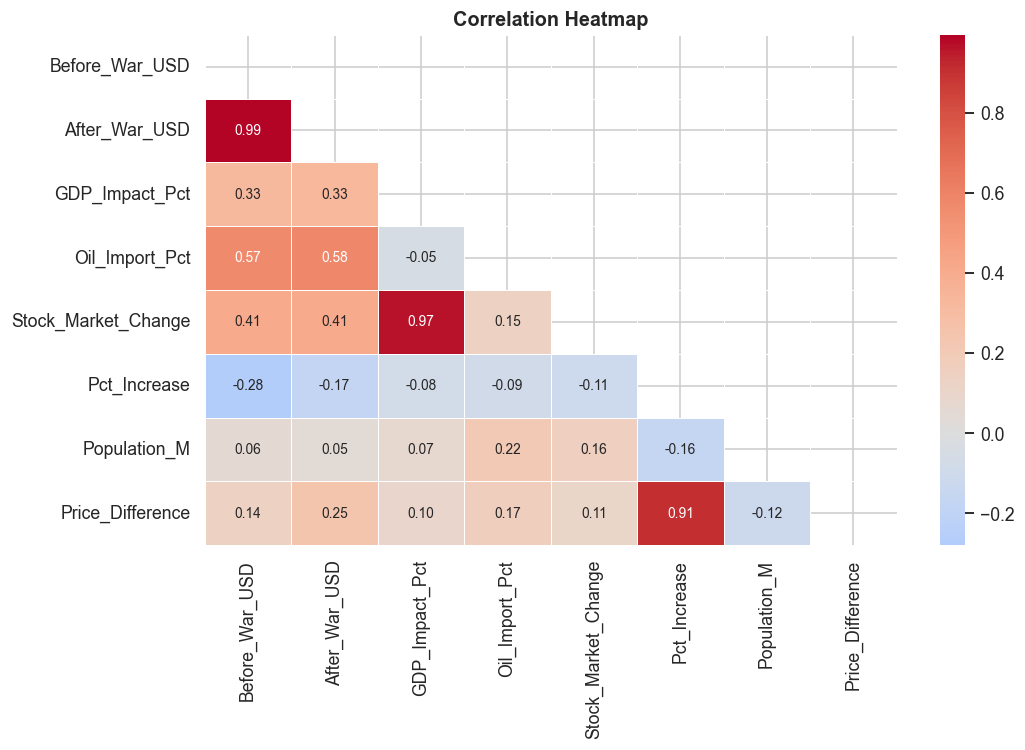

In [40]:
num_df = df[['Before_War_USD','After_War_USD','GDP_Impact_Pct',
             'Oil_Import_Pct','Stock_Market_Change','Pct_Increase',
             'Population_M','Price_Difference']].copy()

corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('v04_heatmap.png', bbox_inches='tight')
plt.show()

### 11.5 Categorical Distributions

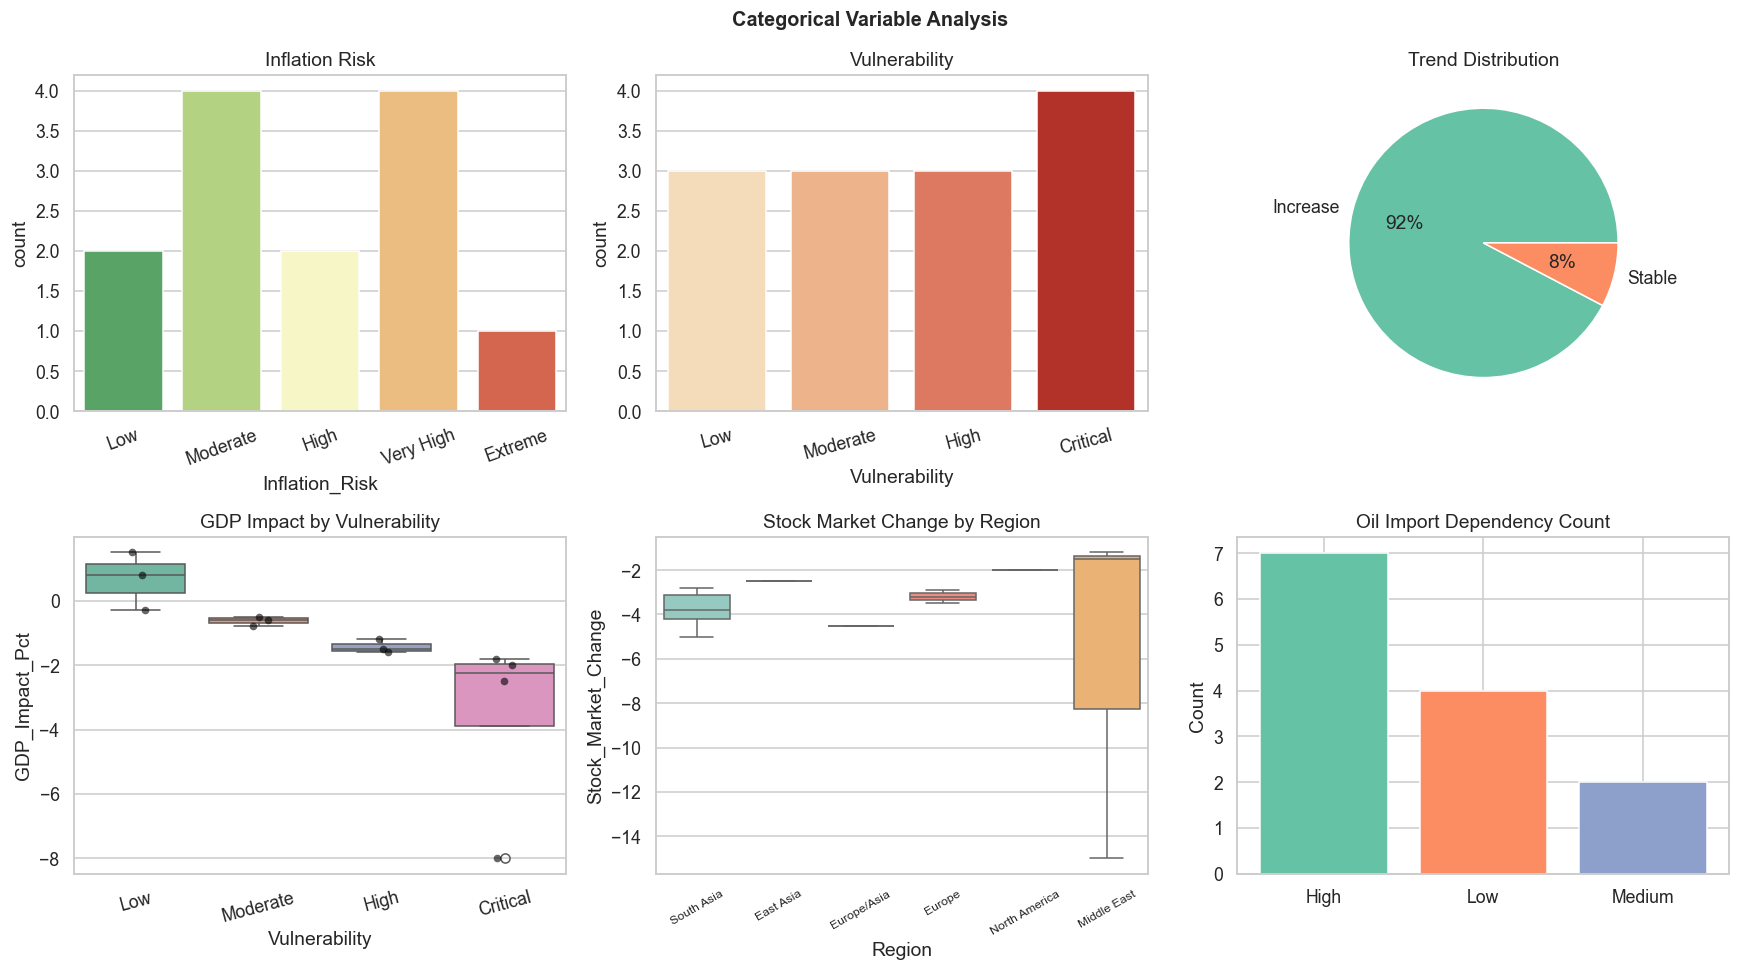

In [41]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Categorical Variable Analysis', fontsize=13, fontweight='bold')

order1 = [o for o in ['Low','Moderate','High','Very High','Extreme'] if o in df['Inflation_Risk'].values]
sns.countplot(data=df, x='Inflation_Risk', order=order1, ax=axes[0,0], palette='RdYlGn_r', edgecolor='white')
axes[0,0].set_title('Inflation Risk')
axes[0,0].tick_params(axis='x', rotation=20)

order2 = [o for o in ['Low','Moderate','High','Critical'] if o in df['Vulnerability'].values]
sns.countplot(data=df, x='Vulnerability', order=order2, ax=axes[0,1], palette='OrRd', edgecolor='white')
axes[0,1].set_title('Vulnerability')
axes[0,1].tick_params(axis='x', rotation=15)

vc = df['Trend'].value_counts()
axes[0,2].pie(vc.values, labels=vc.index, autopct='%1.0f%%',
              colors=sns.color_palette('Set2', len(vc)),
              wedgeprops={'edgecolor':'white'})
axes[0,2].set_title('Trend Distribution')

sns.boxplot(data=df, x='Vulnerability', y='GDP_Impact_Pct', order=order2,
            ax=axes[1,0], palette='Set2')
sns.stripplot(data=df, x='Vulnerability', y='GDP_Impact_Pct', order=order2,
              ax=axes[1,0], color='black', size=5, alpha=0.6)
axes[1,0].set_title('GDP Impact by Vulnerability')
axes[1,0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='Region', y='Stock_Market_Change', ax=axes[1,1], palette='Set3')
axes[1,1].set_title('Stock Market Change by Region')
axes[1,1].tick_params(axis='x', rotation=30, labelsize=8)

vc2 = df['Oil_Import_Dep'].value_counts()
axes[1,2].bar(vc2.index, vc2.values, color=sns.color_palette('Set2', len(vc2)), edgecolor='white')
axes[1,2].set_title('Oil Import Dependency Count')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('v05_categorical.png', bbox_inches='tight')
plt.show()

### 11.6 Scatter — Oil Import vs GDP & Stock Market

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Oil Import % vs Economic Outcomes', fontsize=13, fontweight='bold')

sns.scatterplot(data=df, x='Oil_Import_Pct', y='GDP_Impact_Pct',
                hue='Vulnerability', s=100, ax=axes[0], palette='Set2', edgecolor='grey')
sns.regplot(data=df, x='Oil_Import_Pct', y='GDP_Impact_Pct',
            scatter=False, ax=axes[0], color='crimson',
            line_kws={'linestyle':'--','linewidth':1.5})
for _, row in df.iterrows():
    axes[0].text(row['Oil_Import_Pct']+0.5, row['GDP_Impact_Pct']+0.05,
                 row['ISO'], fontsize=7, alpha=0.8)
axes[0].set_title('Oil Import % vs GDP Impact %')

sc = axes[1].scatter(df['Oil_Import_Pct'], df['Stock_Market_Change'],
                     s=df['Population_M'] * 0.25, alpha=0.7,
                     c=df['GDP_Impact_Pct'], cmap='RdYlGn', edgecolors='grey', linewidth=0.5)
plt.colorbar(sc, ax=axes[1], label='GDP Impact %')
for _, row in df.iterrows():
    axes[1].text(row['Oil_Import_Pct']+0.5, row['Stock_Market_Change']+0.1,
                 row['ISO'], fontsize=7, alpha=0.8)
axes[1].set_xlabel('Oil Import %')
axes[1].set_ylabel('Stock Market Change %')
axes[1].set_title('Bubble: Oil Import vs Stock Market\n(size=Population, color=GDP)')

plt.tight_layout()
plt.savefig('v06_scatter.png', bbox_inches='tight')
plt.show()

### 11.7 Log Transformation — Before vs After

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Original vs Log-Transformed Distributions', fontsize=13, fontweight='bold')

pairs = [('Population_M', 'steelblue'), ('Oil_Import_Pct', 'darkorange')]
for i, (col, color) in enumerate(pairs):
    sns.histplot(df[col], kde=True, ax=axes[i,0], color=color, edgecolor='white')
    axes[i,0].set_title(f'{col} — Original')
    sns.histplot(np.log1p(df[col]), kde=True, ax=axes[i,1], color=color, edgecolor='white', alpha=0.7)
    axes[i,1].set_title(f'{col} — log1p Transformed')

plt.tight_layout()
plt.savefig('v07_log_transform.png', bbox_inches='tight')
plt.show()

### 11.8 Encoding Comparison

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Encoding Comparison', fontsize=13, fontweight='bold')

axes[0].scatter(df['Vulnerability_LE'], df['Vulnerability_OE'],
                c=df['Vulnerability_OE'], cmap='Set1', s=80, edgecolors='grey')
for _, row in df.iterrows():
    axes[0].text(row['Vulnerability_LE']+0.03, row['Vulnerability_OE']+0.03,
                 row['Vulnerability'], fontsize=7)
axes[0].set_xlabel('Label Encoded')
axes[0].set_ylabel('Ordinal Encoded')
axes[0].set_title('Label vs Ordinal (Vulnerability)')

x = np.arange(len(df))
axes[1].plot(x, df['Oil_Import_Pct_MM'], 'o-', label='Min-Max', alpha=0.8)
axes[1].plot(x, (df['Oil_Import_Pct_SS'] - df['Oil_Import_Pct_SS'].min()) /
             (df['Oil_Import_Pct_SS'].max() - df['Oil_Import_Pct_SS'].min()),
             's--', label='Std Scaled (normalised)', alpha=0.8)
axes[1].set_title('Scaling Comparison (Oil Import %)')
axes[1].set_xlabel('Country Index')
axes[1].legend(fontsize=8)

tgt_plot = df[['Region','Region_TargetEnc']].drop_duplicates().sort_values('Region_TargetEnc')
colors = ['tomato' if v < 0 else 'mediumseagreen' for v in tgt_plot['Region_TargetEnc']]
axes[2].barh(tgt_plot['Region'], tgt_plot['Region_TargetEnc'], color=colors, edgecolor='white')
axes[2].axvline(0, color='black', linewidth=0.7)
axes[2].set_title('Target Encoding — Region → Mean GDP Impact')
axes[2].set_xlabel('Mean GDP Impact %')

plt.tight_layout()
plt.savefig('v08_encoding_comparison.png', bbox_inches='tight')
plt.show()

### 11.9 Region-wise Aggregations

In [ ]:
region_agg = df.groupby('Region')[['Oil_Import_Pct','GDP_Impact_Pct','Stock_Market_Change']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Region-wise Average Indicators', fontsize=13, fontweight='bold')

for ax, (col, color) in zip(axes, [
    ('Oil_Import_Pct',      'teal'),
    ('GDP_Impact_Pct',      'steelblue'),
    ('Stock_Market_Change', 'tomato')
]):
    sd = region_agg.sort_values(col)
    bars = ax.barh(sd['Region'], sd[col], color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'Avg {col.replace("_"," ")}')
    for bar, val in zip(bars, sd[col]):
        ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('v09_region.png', bbox_inches='tight')
plt.show()